# Task 5 — Classification Model Evaluation

In [25]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

In [26]:
df = pd.read_csv("cardio_train.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62,110,80,1,1,0,0,1,0
1,1,20228,1,156,85,140,90,3,1,0,0,1,1
2,2,18857,1,165,64,130,70,3,1,0,0,0,1
3,3,17623,2,169,82,150,100,1,1,0,0,1,1
4,4,17474,1,156,56,100,60,1,1,0,0,0,0


In [27]:
X = df.drop(columns=["cardio"])
y = df["cardio"]

print("Features:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

Target distribution:
cardio
0    35021
1    34979
Name: count, dtype: int64


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 56000
Testing samples : 14000


In [29]:
# MODELS

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric="logloss"
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [30]:
# All CLASSIFICATION MODELS
trained_models = {}
predictions = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    trained_models[name] = model
    predictions[name] = y_pred

print("\nAll models trained successfully.")


Training Logistic Regression...

Training Random Forest...

Training XGBoost...

Training AdaBoost...

Training Gradient Boosting...

All models trained successfully.


In [31]:
# MODEL EVALUATION

results = []

for name, model in trained_models.items():

    y_pred = predictions[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)

print("CLASSIFICATION MODEL COMPARISON")
display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

CLASSIFICATION MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.7124,0.7295,0.6768,0.7022
1,Random Forest,0.7239,0.7363,0.6989,0.7171
2,XGBoost,0.7391,0.7596,0.7011,0.7292
3,AdaBoost,0.7204,0.7771,0.6194,0.6893
4,Gradient Boosting,0.7376,0.7536,0.7075,0.7298


In [32]:
# REPORTS
for name, y_pred in predictions.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "No Cardiovascular Disease",
                "Cardiovascular Disease"
            ],
            zero_division=0
        )
    )


Logistic Regression
                           precision    recall  f1-score   support

No Cardiovascular Disease       0.70      0.75      0.72      6988
   Cardiovascular Disease       0.73      0.68      0.70      7012

                 accuracy                           0.71     14000
                macro avg       0.71      0.71      0.71     14000
             weighted avg       0.71      0.71      0.71     14000


Random Forest
                           precision    recall  f1-score   support

No Cardiovascular Disease       0.71      0.75      0.73      6988
   Cardiovascular Disease       0.74      0.70      0.72      7012

                 accuracy                           0.72     14000
                macro avg       0.72      0.72      0.72     14000
             weighted avg       0.72      0.72      0.72     14000


XGBoost
                           precision    recall  f1-score   support

No Cardiovascular Disease       0.72      0.78      0.75      6988
   Cardiov

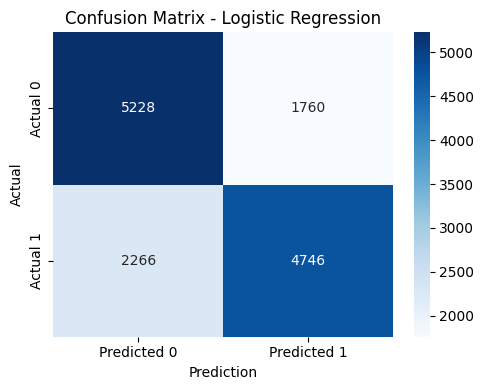

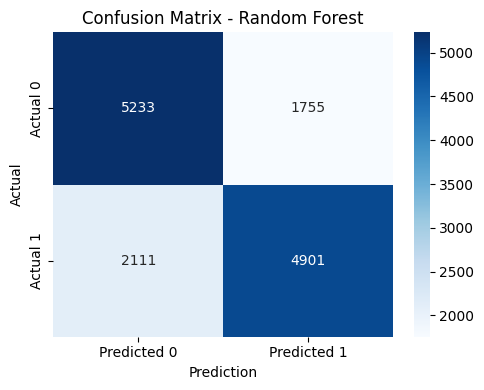

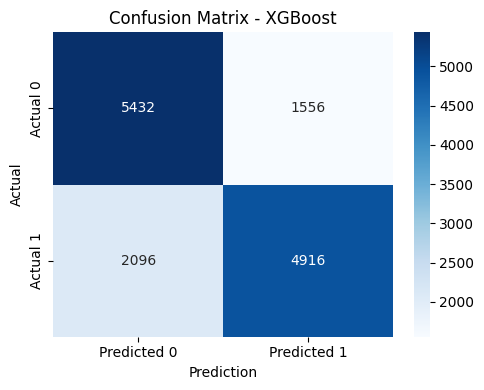

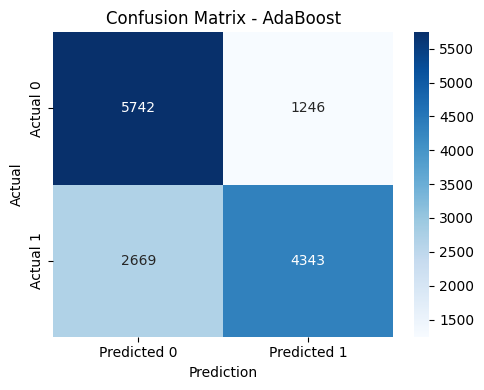

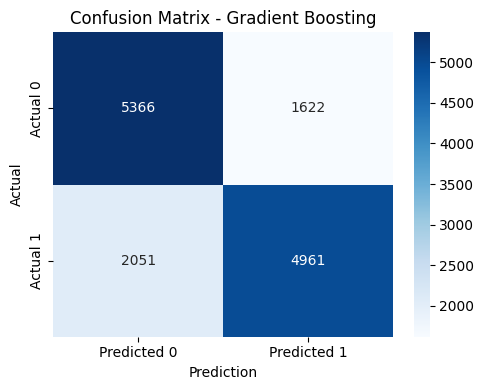

In [33]:
# CONFUSION MATRICES

for name, y_pred in predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Prediction")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [34]:
# Train score vs Test score

fit_results = []

for name, model in trained_models.items():

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    fit_results.append({
        "Model": name,
        "Train Accuracy": train_score,
        "Test Accuracy": test_score,
        "Difference": train_score - test_score
    })

fit_df = pd.DataFrame(fit_results)

display(
    fit_df.style.format({
        "Train Accuracy": "{:.4f}",
        "Test Accuracy": "{:.4f}",
        "Difference": "{:.4f}"
    })
)

,Model,Train Accuracy,Test Accuracy,Difference
0,Logistic Regression,0.7056,0.7124,-0.0068
1,Random Forest,1.0000,0.7239,0.2761
2,XGBoost,0.7431,0.7391,0.0040
3,AdaBoost,0.7188,0.7204,-0.0015
4,Gradient Boosting,0.7376,0.7376,-0.0001


In [35]:
# SIMPLE FIT INTERPRETATION

for _, row in fit_df.iterrows():

    train = row["Train Accuracy"]
    test = row["Test Accuracy"]
    gap = row["Difference"]

    if gap > 0.10:
        status = "Possible Overfitting"
    elif train < 0.65 and test < 0.65:
        status = "Possible Underfitting"
    else:
        status = "Reasonably Good Fit"

    print(
        f'{row["Model"]}: '
        f'Train={train:.4f}, Test={test:.4f}, '
        f'Gap={gap:.4f} -> {status}'
    )

Logistic Regression: Train=0.7056, Test=0.7124, Gap=-0.0068 -> Reasonably Good Fit
Random Forest: Train=1.0000, Test=0.7239, Gap=0.2761 -> Possible Overfitting
XGBoost: Train=0.7431, Test=0.7391, Gap=0.0040 -> Reasonably Good Fit
AdaBoost: Train=0.7188, Test=0.7204, Gap=-0.0015 -> Reasonably Good Fit
Gradient Boosting: Train=0.7376, Test=0.7376, Gap=-0.0001 -> Reasonably Good Fit


In [36]:
# 5-FOLD CROSS-VALIDATION

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV Precision Mean": scores["test_precision"].mean(),
        "CV Recall Mean": scores["test_recall"].mean(),
        "CV F1 Mean": scores["test_f1"].mean()
    })

cv_df = pd.DataFrame(cv_results)

print("5-FOLD CROSS-VALIDATION")
display(
    cv_df.style.format({
        "CV Accuracy Mean": "{:.4f}",
        "CV Accuracy Std": "{:.4f}",
        "CV Precision Mean": "{:.4f}",
        "CV Recall Mean": "{:.4f}",
        "CV F1 Mean": "{:.4f}"
    })
)

5-FOLD CROSS-VALIDATION


,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean
0,Logistic Regression,0.7044,0.0078,0.7211,0.6656,0.6922
1,Random Forest,0.7240,0.0034,0.7349,0.6996,0.7168
2,XGBoost,0.7349,0.0045,0.7548,0.6950,0.7236
3,AdaBoost,0.7174,0.0042,0.7749,0.6118,0.6837
4,Gradient Boosting,0.7334,0.0041,0.7505,0.6984,0.7235


In [ ]:
# MODEL FOR HYPERPARAMETER TUNING

best_model_name = "XGBoost"

print("Model selected for hyperparameter tuning:", best_model_name)

In [16]:
# 15. XGBOOST HYPERPARAMETER TUNING

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(round(grid_search.best_score_, 4))

tuned_xgb = grid_search.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

Best Cross-Validation F1-score:
0.726


In [17]:
# RETEST TUNED MODEL ON TEST SET

tuned_pred = tuned_xgb.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(
    y_test, tuned_pred, zero_division=0
)
tuned_recall = recall_score(
    y_test, tuned_pred, zero_division=0
)
tuned_f1 = f1_score(
    y_test, tuned_pred, zero_division=0
)

print("\nTUNED XGBOOST TEST RESULTS")
print("--------------------------------")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1-score :", round(tuned_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        tuned_pred,
        target_names=[
            "No Cardiovascular Disease",
            "Cardiovascular Disease"
        ],
        zero_division=0
    )
)


TUNED XGBOOST TEST RESULTS
--------------------------------
Accuracy : 0.7333
Precision: 0.7527
Recall   : 0.6944
F1-score : 0.7224

Classification Report:
                           precision    recall  f1-score   support

No Cardiovascular Disease       0.72      0.77      0.74      7004
   Cardiovascular Disease       0.75      0.69      0.72      6996

                 accuracy                           0.73     14000
                macro avg       0.73      0.73      0.73     14000
             weighted avg       0.73      0.73      0.73     14000



In [18]:
# COMPARE ORIGINAL VS TUNED XGBOOST

original_xgb = results_df[
    results_df["Model"] == "XGBoost"
].iloc[0]

xgb_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Original XGBoost": [
        original_xgb["Accuracy"],
        original_xgb["Precision"],
        original_xgb["Recall"],
        original_xgb["F1-score"]
    ],
    "Tuned XGBoost": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

display(
    xgb_comparison.style.format({
        "Original XGBoost": "{:.4f}",
        "Tuned XGBoost": "{:.4f}"
    })
)

,Metric,Original XGBoost,Tuned XGBoost
0,Accuracy,0.7331,0.7333
1,Precision,0.7517,0.7527
2,Recall,0.6957,0.6944
3,F1-score,0.7226,0.7224


In [19]:
# CHECK WHETHER TUNING IMPROVED TEST F1

improvement = tuned_f1 - original_xgb["F1-score"]

print(
    "F1-score improvement:",
    round(improvement, 4)
)

if improvement > 0:
    print("Tuned XGBoost improved the test F1-score.")
else:
    print(
        "Tuned XGBoost did not improve the test F1-score. "
        "The original model may be preferable based on this metric."
    )

F1-score improvement: -0.0002
Tuned XGBoost did not improve the test F1-score. The original model may be preferable based on this metric.


In [20]:
# FINAL MODEL COMPARISON TABLE

final_comparison = results_df.copy()

tuned_row = pd.DataFrame([{
    "Model": "Tuned XGBoost",
    "Accuracy": tuned_accuracy,
    "Precision": tuned_precision,
    "Recall": tuned_recall,
    "F1-score": tuned_f1
}])

final_comparison = pd.concat(
    [final_comparison, tuned_row],
    ignore_index=True
)

display(
    final_comparison.sort_values(
        by="F1-score",
        ascending=False
    ).style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-score
4,Gradient Boosting,0.7329,0.7500,0.6983,0.7232
2,XGBoost,0.7331,0.7517,0.6957,0.7226
5,Tuned XGBoost,0.7333,0.7527,0.6944,0.7224
1,Random Forest,0.7229,0.7320,0.7027,0.7170
0,Logistic Regression,0.7031,0.7190,0.6662,0.6916
3,AdaBoost,0.7162,0.7704,0.6155,0.6843


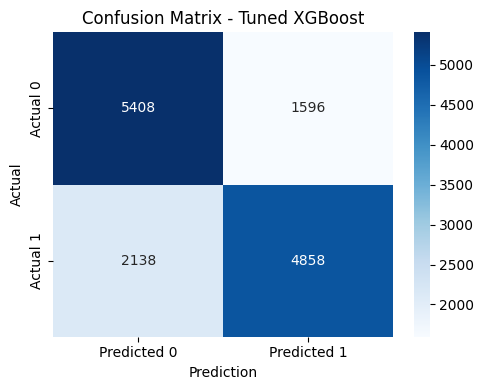

In [21]:
# FINAL TUNED MODEL CONFUSION MATRIX

cm = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

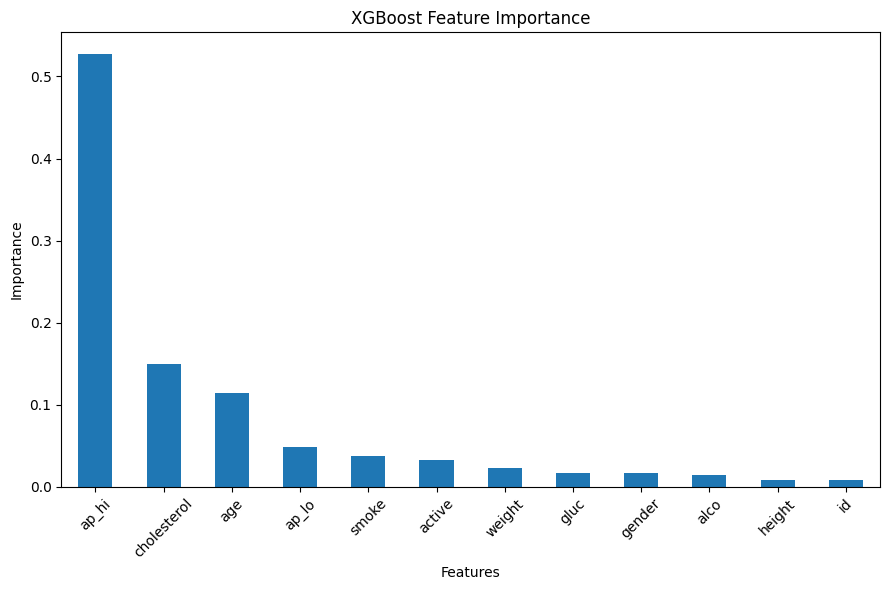

Feature Importance:


,Importance
ap_hi,0.527361
cholesterol,0.149993
age,0.114403
ap_lo,0.048898
smoke,0.037502
active,0.033338
weight,0.023577
gluc,0.017515
gender,0.016736
alco,0.014785


In [22]:
# FEATURE IMPORTANCE

importance = pd.Series(
    tuned_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))

importance.plot(kind="bar")

plt.title("XGBoost Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Feature Importance:")
display(importance.to_frame("Importance"))

In [23]:
# SAVE FINAL MODEL

import joblib

model_package = {
    "model": tuned_xgb,
    "scaler": None,
    "features": X.columns.tolist()
}

joblib.dump(
    model_package,
    "cardiovascular_xgboost_task5.pkl"
)

print("Final model saved as cardiovascular_xgboost_task5.pkl")

Final model saved as cardiovascular_xgboost_task5.pkl
